# HW 1

## Problem 5

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = 1
der = np.cos(1)

hs = [10**-i for i in range(0,16)]

In [4]:
errors = []
for h in hs:
    approx_der = (np.sin(x+h)-np.sin(x-h))/(2*h) # this line modified to use central differences
    error = np.abs(der-approx_der)
    errors.append(error)

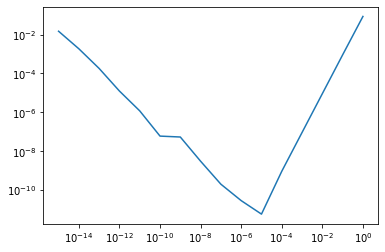

In [7]:
plt.loglog(hs, errors)

In [10]:
np.log((errors[2]-errors[3]))/np.log((hs[2]-hs[3])) # slope interpretation

2.4684653250743973

This indicates that reducing $h$ by a factor of $10$ reduces error by a factor of approximately $10^{2.4}$

Here, $10^{-5}$ seems to have the smallest error.

****
## Problem 6

In [11]:
x = 1.2e-8

top = 1- np.cos(x)
bottom = x**2

top/bottom

0.7709882115452477

This is significantly larger than the max we expect of $0.5$

In [12]:
new_top = 2*np.sin(x/2)**2

new_top/bottom

0.5

$0.5$ is our expected answer based off our calculation!

****
## Problem 7

In [13]:
def fun(prev, n):
    return 2**(n+1)*(np.sqrt(1+(prev/2**n)**2)-1)/(prev/2**n)

<ipython-input-13-8aa4dc0cc4d4>:2: RuntimeWarning: invalid value encountered in double_scalars
  return 2**(n+1)*(np.sqrt(1+(prev/2**n)**2)-1)/(prev/2**n)


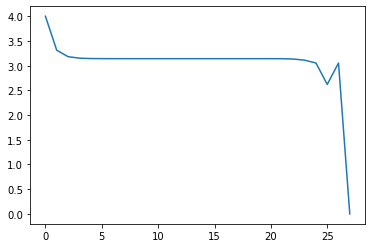

In [25]:
t_list = [4]

for i in range(2,30):
    t_list.append(fun(t_list[i-2], i))

plt.plot(t_list)

In [32]:
t_list

[4,
 3.313708498984761,
 3.1825978780745294,
 3.151724907429258,
 3.1441183852458665,
 3.142223629942345,
 3.141750369169704,
 3.141632080702249,
 3.141602510241972,
 3.1415951177183654,
 3.1415932696317452,
 3.1415928083796847,
 3.1415926909629692,
 3.141592675570452,
 3.1415926909629692,
 3.1415925237884728,
 3.1415908695791153,
 3.1415925237884728,
 3.141600583626336,
 3.1415925237884728,
 3.141445158870801,
 3.140970795602487,
 3.1339832938853593,
 3.1110567880253206,
 3.0536247478882985,
 2.6198372951792175,
 3.0536247478882985,
 0.0,
 nan]

As n increases, $t_n/2^n$ goes to zero. So we have cancellation in the numerator for large $n$.

We can adjust our function by multiplying by fancy 1, that is, by $\frac{\sqrt{1+(t_n/2^n)^2}}{\sqrt{1+(t_n/2^n)^2}}$

In [29]:
def fun2(prev, n):
    return 2*(prev)/((np.sqrt(1+(prev/2**n)**2)+1))

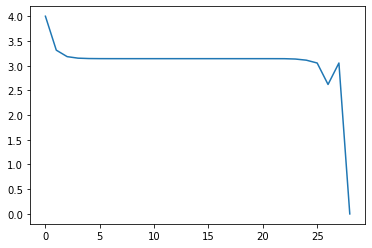

In [30]:
t_list2 = [4]

for i in range(2,30):
    t_list2.append(fun2(t_list[i-2], i))

plt.plot(t_list2)

In [27]:
t_list2

[4,
 3.3137084989847607,
 3.1825978780745294,
 3.151724907429257,
 3.1441183852459065,
 3.142223629942419,
 3.1417503691688546,
 3.14163208070392,
 3.1416025102558764,
 3.1415951177347523,
 3.1415932695980833,
 3.1415928076020823,
 3.141592692872295,
 3.141592662086123,
 3.141592668351241,
 3.1415926891581663,
 3.1415925233372723,
 3.141590869466315,
 3.1415925237602726,
 3.141600583619286,
 3.1415925237867106,
 3.1414451588703596,
 3.1409707956023767,
 3.1339832938853323,
 3.1110567880253135,
 3.053624747888297,
 2.6198372951792175,
 3.0536247478882985,
 nan]

In [31]:
# to be honest I dont know why this breaks at the end

****
## Problem 9

In [36]:
def exp_approximator(x):
    prev = 1
    cur = 1+x
    add = x
    n = 2
    while(prev != cur):
        prev = cur
        add = add*x/n
        cur += add
        n+=1
    return cur

In [38]:
approx = exp_approximator(-15)
approx

3.0590941973020066e-07

In [39]:
rel_error = np.abs(np.exp(-15)-approx)/np.exp(-15)

rel_error

2.320750088861551e-05

Can I think of a better way to do this? maybe. This approximation is pretty good, in my opinion. The issue might come from how many times we iterate over our loop. That is, the algorithm might not be the most efficient, but it is accurate.